# Decision Transformer for Limit Order Book Trading

**Authors:** Côme Genet & Clément Callaer — CentraleSupélec, 2026

---

This project explores an **Offline Reinforcement Learning** approach to financial market trading by framing the RL problem as a **conditional sequence modeling task**. Instead of relying on traditional value-based methods (TD learning, policy gradients), we implement a **Decision Transformer** architecture built from scratch in PyTorch.

## 1. Finance Background: what is a Limit Order Book?

A **Limit Order Book (LOB)** is the electronic table used by an exchange to match buyers and sellers.

- A **bid** is an intention to buy at a given price.
- An **ask** is an intention to sell at a given price.
- Orders are organized by **price level**: level 1 is the best currently available price, level 2 the next best, and so on.

At time $t$, the best prices are:

$$
 p_b^{(1)}(t) = \text{best bid}, \qquad p_a^{(1)}(t) = \text{best ask}
$$

The **mid-price** is the average of the two and is often used as a reference price:

$$
 m_t = \frac{p_a^{(1)}(t) + p_b^{(1)}(t)}{2}
$$

The **spread** measures the distance between buyers and sellers:

$$
 s_t = p_a^{(1)}(t) - p_b^{(1)}(t)
$$

Each level also has an available **volume**:

$$
 v_a^{(i)}(t), \; v_b^{(i)}(t), \qquad i = 1, \dots, 10
$$

So one snapshot of the book contains price and volume information on both sides:

$$
 x_t = \left[p_a^{(1)}, v_a^{(1)}, p_b^{(1)}, v_b^{(1)}, \dots, p_a^{(10)}, v_a^{(10)}, p_b^{(10)}, v_b^{(10)}\right]
$$

This is the core object studied in high-frequency finance: instead of only observing the traded price, we observe the **supply and demand close to the market price**.

A useful intuition is that the LOB is a very short-term picture of market pressure:
- more buy volume near the best bid can indicate upward pressure,
- more sell volume near the best ask can indicate downward pressure,
- a narrow spread usually indicates better liquidity.

One classical feature is the **imbalance** at the best level:

$$
 I_t = \frac{v_b^{(1)}(t)}{v_a^{(1)}(t) + v_b^{(1)}(t)}
$$

If $I_t$ is high, the buy side is relatively stronger; if it is low, the sell side is relatively stronger. This is one example of a microstructure feature that can help predict short-term price moves.

## 2. Dataset — FI-2010 Limit Order Book

The **FI-2010** benchmark dataset, introduced in `arXiv 1705.03233`, is one of the first public benchmark datasets for **mid-price prediction from LOB data**. It contains high-frequency order book data for **5 Finnish stocks** over **10 consecutive trading days** from the Helsinki exchange.

This matters because most real LOB datasets are proprietary. FI-2010 became a standard benchmark precisely because it makes reproducible experiments possible.

In the processed representation used here, each event is described by **149 rows**:

- **Rows 0-39:** raw LOB information for the first 10 levels
  $$
  10 \text{ levels} \times 4 \text{ values per level} = 40 \text{ raw features}
  $$
  with `ask price, ask volume, bid price, bid volume`.
- **Rows 40-143:** **104 engineered features** built from the raw book.
- **Rows 144-148:** labels for **5 prediction horizons**.

The full predictive vector therefore has **144 input features** before the label rows.

### What the engineered features represent

Following the dataset paper, the 104 engineered features are not arbitrary: they summarize economically meaningful properties of the book.

They include:
- **Spread and mid-price features**: how far bid and ask are from each other, and the current reference price.
- **Price difference features**: how prices change across levels of the book.
- **Average price and volume features**: summary statistics of liquidity on both sides.
- **Accumulated differences**: total buy-side versus sell-side pressure.
- **Time-sensitive derivatives**: how prices and volumes evolve over recent events.
- **Order-intensity features**: frequencies of submissions, cancellations, and executions.

For a non-finance audience, the key idea is simple: the dataset does not only store the current order book, it also stores **summaries of its geometry and recent dynamics**.

### Labels: what are we trying to predict?

The target is not the exact future price, but the **direction of the future mid-price movement**.

In the FI-2010 benchmark, labels are created from a smoothed future return:

$$
 l_t^{(k)} = \frac{\frac{1}{k}\sum_{j=t+1}^{t+k} m_j - m_t}{m_t}
$$

where $k$ is the prediction horizon in number of future events.

The label is then discretized into three classes:

$$
 y_t =
\begin{cases}
+1 & \text{if } l_t^{(k)} > \alpha \\
0 & \text{if } |l_t^{(k)}| \le \alpha \\
-1 & \text{if } l_t^{(k)} < -\alpha
\end{cases}
$$

So the machine learning task is a **3-class classification problem**: predict whether the mid-price will go **up**, **stay approximately unchanged**, or **go down**.

### Important dataset characteristics to mention in a presentation

For a professor not familiar with finance, these are the main takeaways:

- The data is **event-based**, not sampled every second. One observation corresponds to a book update.
- The market is represented through the **top 10 bid and ask levels**, not only the last traded price.
- The dataset is already **normalized**, because the original exchange data cannot be publicly released in raw form.
- The benchmark focuses on **very short-term forecasting** in market microstructure.
- The labels are based on the **mid-price**, which is more stable than transaction prices at ultra-high frequency.

We download the public benchmark version from Kaggle using `kagglehub`. 

## 3. Why the two papers matter for this project

### `arXiv 1705.03233` — the dataset paper

This paper is the reference for the **construction of FI-2010**. Its main contributions are:

- it releases a rare **public LOB benchmark**,
- it defines a reproducible **evaluation protocol**,
- it provides the **144-dimensional representation** and the 3-class labels,
- it shows baseline results for traditional machine learning models.

Conceptually, this paper answers: **what is the data, how is it built, and what exactly should be predicted?**

It also explains several finance-specific choices that are easy to miss:
- auction periods are treated separately because market behavior there is structurally different,
- event time is preferred to clock time because market activity is irregular,
- class imbalance makes **F1-score** more informative than accuracy alone.

### `arXiv 1808.03668` — the modelling paper (DeepLOB)

This paper starts from the FI-2010 benchmark and asks a different question: **can a neural network learn useful features directly from raw LOB states?**

Its main message is that hand-crafted features are helpful, but deep models can often learn better internal representations from the raw 40-dimensional LOB input over a short history window.

The paper uses sequences of LOB states:

$$
X_t \in \mathbb{R}^{100 \times 40}
$$

meaning that the model observes the **100 most recent book states**, each with **40 raw features**.

A key idea in DeepLOB is that convolutional layers can detect local price-volume patterns across levels, while LSTMs can capture temporal structure across recent events. In finance terms, the model tries to learn:
- local **supply-demand imbalances**,
- short-term **liquidity shocks**,
- recurring **microstructure patterns** that precede price changes.

The paper also highlights one important practical point: FI-2010 is very useful, but it is **small and highly processed** compared with real industrial datasets. So it is excellent for benchmarking, but not sufficient on its own to prove real-world trading robustness.

### Connection with our notebook

These two papers play complementary roles:

- `1705.03233` tells us **how the benchmark dataset is built** and how labels are defined.
- `1808.03668` tells us **why LOB data contains predictive structure** and how deep models can exploit it.

In other words:
- the first paper gives the **data representation and benchmark task**,
- the second paper gives a **modern learning architecture and interpretation of useful LOB features**.

That is why FI-2010 is still widely used in machine learning for finance: it provides a common testbed for comparing architectures, from classical models to deep sequence models.


## Project Roadmap

The goal of this notebook is to build a **Decision Transformer** agent that learns to trade on Limit Order Book data using **Offline Reinforcement Learning**. The full pipeline is:

1. **Import libraries** — load all dependencies (NumPy, PyTorch, etc.).
2. **Load the dataset** — download and parse the FI-2010 benchmark.
3. **Explore & preprocess the data** — inspect feature distributions, build state representations, and split into train/test.
4. **Define the trading environment** — formalize the state space, action space ($\{-1, 0, +1\}$), and reward function with transaction costs.
5. **Generate offline trajectories** — run a heuristic policy to produce $(s, a, r, \hat{R})$ sequences for offline training.
6. **Build the Decision Transformer** — implement the GPT-style architecture from scratch in PyTorch.
7. **Train the model** — optimize the sequence model on the offline dataset.
8. **Evaluate & backtest** — measure the agent's performance (cumulative PnL, Sharpe ratio, comparison with baselines).
9. **Analysis & visualization** — interpret the learned policy and present results.

---

## 4. Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from pathlib import Path
import os
import kagglehub

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device   : {device}")

PyTorch version: 2.6.0
CUDA available : False
Using device   : cpu


## 5. Load the Dataset

We download the FI-2010 benchmark from Kaggle using `kagglehub`, then load the **Z-score normalized, no-auction** variant — the standard setting used in most published benchmarks. The data files are concatenated along the time axis to form one large matrix of shape $(149, T)$ where $T$ is the total number of events across all cross-validation folds.

In [4]:
dataset_path = Path(kagglehub.dataset_download("ulfricirons/fi-2010"))
print(f"Dataset downloaded to: {dataset_path}")

for root, dirs, files in os.walk(dataset_path):
    for f in files:
        rel = os.path.relpath(os.path.join(root, f), dataset_path)
        print(f"  {rel}")

100%|██████████| 1.95G/1.95G [15:23<00:00, 2.27MB/s]

Extracting files...


Dataset downloaded to: /Users/comegenet/.cache/kagglehub/datasets/ulfricirons/fi-2010/versions/1
  BenchmarkDatasets/Auction/2.Auction_MinMax/Auction_MinMax_Testing/Test_Dst_Auction_MinMax_CF_8.txt
  BenchmarkDatasets/Auction/2.Auction_MinMax/Auction_MinMax_Testing/Test_Dst_Auction_MinMax_CF_9.txt
  BenchmarkDatasets/Auction/2.Auction_MinMax/Auction_MinMax_Testing/Test_Dst_Auction_MinMax_CF_4.txt
  BenchmarkDatasets/Auction/2.Auction_MinMax/Auction_MinMax_Testing/Test_Dst_Auction_MinMax_CF_5.txt
  BenchmarkDatasets/Auction/2.Auction_MinMax/Auction_MinMax_Testing/Test_Dst_Auction_MinMax_CF_7.txt
  BenchmarkDatasets/Auction/2.Auction_MinMax/Auction_MinMax_Testing/Test_Dst_Auction_MinMax_CF_6.txt
  BenchmarkDatasets/Auction/2.Auction_MinMax/Auction_MinMax_Testing/Test_Dst_Auction_MinMax_CF_2.txt
  BenchmarkDatasets/Auction/2.Auction_MinMax/Auction_MinMax_Testing/Test_Dst_Auction_MinMax_CF_3.txt
  BenchmarkDatasets/Auction/2.Auction_MinMax/Auction_MinMax_Testing/Test_Dst_Auction_MinMax_CF_

In [5]:
# Load the Z-score normalized, no-auction data (standard benchmark setting)
# Adjust the glob pattern below if the directory structure differs after download.
zscore_files = sorted(dataset_path.rglob("*NoAuction_Zscore*/*.txt"))

if not zscore_files:
    # Fallback: try to find any .txt files
    zscore_files = sorted(dataset_path.rglob("*.txt"))
    print(f"Could not find NoAuction_Zscore folder — found {len(zscore_files)} .txt file(s) total.")

print(f"Found {len(zscore_files)} data file(s):")
for f in zscore_files:
    print(f"  {f.name}")

# Load all files and concatenate along the time axis (columns)
arrays = [np.loadtxt(f) for f in zscore_files]
data = np.hstack(arrays)  # shape: (149, total_timesteps)
print(f"\nCombined data shape: {data.shape}  (149 rows × {data.shape[1]} timesteps)")

Found 18 data file(s):
  Test_Dst_NoAuction_ZScore_CF_1.txt
  Test_Dst_NoAuction_ZScore_CF_2.txt
  Test_Dst_NoAuction_ZScore_CF_3.txt
  Test_Dst_NoAuction_ZScore_CF_4.txt
  Test_Dst_NoAuction_ZScore_CF_5.txt
  Test_Dst_NoAuction_ZScore_CF_6.txt
  Test_Dst_NoAuction_ZScore_CF_7.txt
  Test_Dst_NoAuction_ZScore_CF_8.txt
  Test_Dst_NoAuction_ZScore_CF_9.txt
  Train_Dst_NoAuction_ZScore_CF_1.txt
  Train_Dst_NoAuction_ZScore_CF_2.txt
  Train_Dst_NoAuction_ZScore_CF_3.txt
  Train_Dst_NoAuction_ZScore_CF_4.txt
  Train_Dst_NoAuction_ZScore_CF_5.txt
  Train_Dst_NoAuction_ZScore_CF_6.txt
  Train_Dst_NoAuction_ZScore_CF_7.txt
  Train_Dst_NoAuction_ZScore_CF_8.txt
  Train_Dst_NoAuction_ZScore_CF_9.txt

Combined data shape: (149, 2045191)  (149 rows × 2045191 timesteps)


In [6]:
# Separate LOB features and labels
lob_features = data[:40, :]       # 10 levels × 4 (ask_price, ask_vol, bid_price, bid_vol)
handcrafted   = data[40:144, :]   # 104 hand-crafted features
labels        = data[144:, :]     # 5 label rows for horizons k=10,20,30,50,100

print("LOB features shape :", lob_features.shape)
print("Hand-crafted shape :", handcrafted.shape)
print("Labels shape       :", labels.shape)

# Transpose to (timesteps, features) — standard ML convention
X_lob = lob_features.T
X_all = data[:144, :].T
y     = labels.T

print(f"\nFeature matrix (LOB only) : {X_lob.shape}  (timesteps × 40)")
print(f"Feature matrix (all feat.): {X_all.shape}  (timesteps × 144)")
print(f"Label matrix              : {y.shape}  (timesteps × 5 horizons)")

LOB features shape : (40, 2045191)
Hand-crafted shape : (104, 2045191)
Labels shape       : (5, 2045191)

Feature matrix (LOB only) : (2045191, 40)  (timesteps × 40)
Feature matrix (all feat.): (2045191, 144)  (timesteps × 144)
Label matrix              : (2045191, 5)  (timesteps × 5 horizons)


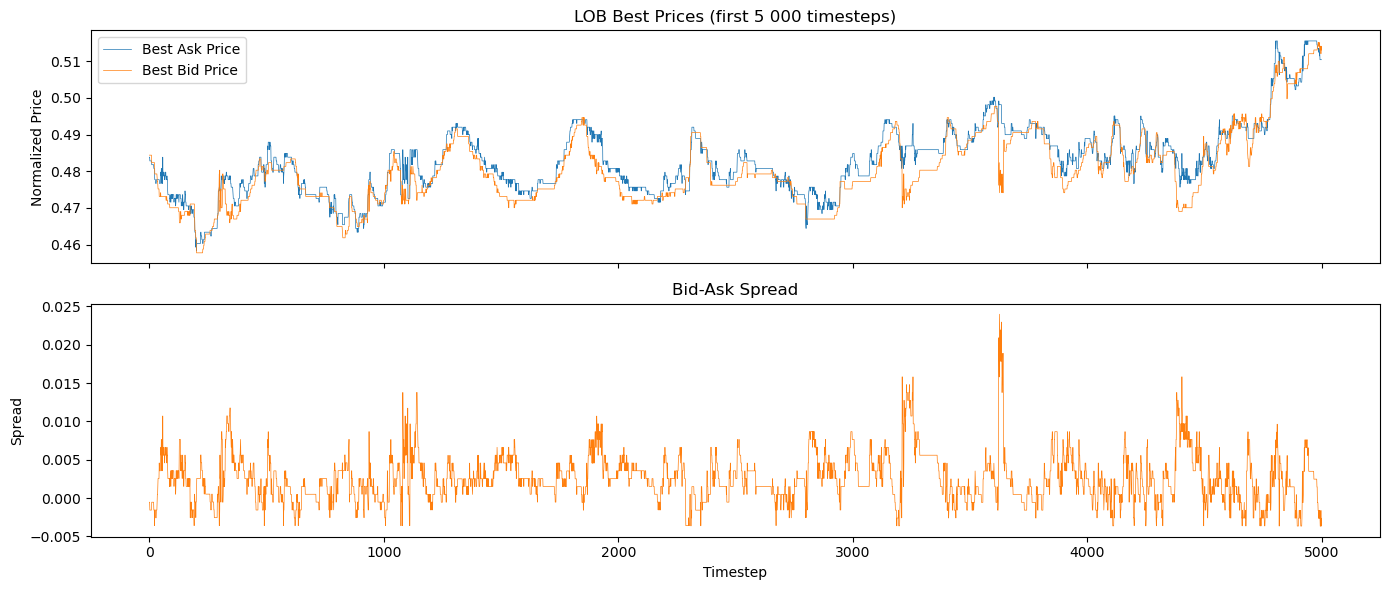

In [7]:
# Quick visualization: best ask & bid prices over time
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

n_display = min(5000, X_lob.shape[0])

axes[0].plot(X_lob[:n_display, 0], linewidth=0.5, label="Best Ask Price")
axes[0].plot(X_lob[:n_display, 2], linewidth=0.5, label="Best Bid Price")
axes[0].set_ylabel("Normalized Price")
axes[0].legend()
axes[0].set_title("LOB Best Prices (first 5 000 timesteps)")

spread = X_lob[:n_display, 0] - X_lob[:n_display, 2]
axes[1].plot(spread, linewidth=0.5, color="tab:orange")
axes[1].set_ylabel("Spread")
axes[1].set_xlabel("Timestep")
axes[1].set_title("Bid-Ask Spread")

plt.tight_layout()
plt.show()

## 5b. Data Quality Checks

Before building the trading environment, we need to understand two properties of the data that directly affect the reward signal:

1. **Label encoding**: the FI-2010 labels may be encoded as `{1, 2, 3}` or `{0, 1, 2}` depending on the version. The momentum policy depends on this.
2. **Day boundaries**: the dataset concatenates multiple cross-validation folds and multiple days. Between two consecutive days, the mid-price can jump discontinuously. An episode that straddles a day boundary will produce a spurious reward spike, not a real trading signal.

We detect these boundaries by looking for large absolute jumps in the mid-price series and exclude them from episode placement.

In [15]:
# =====================================================================
# 5b.1  Check label encoding
# =====================================================================
print("Unique label values per horizon:")
for h in range(y.shape[1]):
    print(f"  horizon {h}: {np.unique(y[:, h])}")

# =====================================================================
# 5b.2  Compute mid-prices and detect day boundaries
# =====================================================================
mid_prices = (X_lob[:, 0] + X_lob[:, 2]) / 2.0

# Day boundaries show up as large jumps in the (normalized) mid-price.
# We flag any timestep where |delta_mid| exceeds a threshold.
delta_mid = np.abs(np.diff(mid_prices))
JUMP_THRESHOLD = np.percentile(delta_mid, 99.9)  # top 0.1% jumps
boundary_mask = delta_mid > JUMP_THRESHOLD
boundary_indices = np.where(boundary_mask)[0]

print(f"\nMid-prices shape: {mid_prices.shape}")
print(f"Mid-prices range: [{mid_prices.min():.4f}, {mid_prices.max():.4f}]")
print(f"Mean spread (normalized): {(X_lob[:, 0] - X_lob[:, 2]).mean():.6f}")
print(f"\nJump threshold (99.9th percentile): {JUMP_THRESHOLD:.6f}")
print(f"Detected {len(boundary_indices)} potential day/fold boundaries")
print(f"Boundary positions (first 20): {boundary_indices[:20]}")


Unique label values per horizon:
  horizon 0: [1. 2. 3.]
  horizon 1: [1. 2. 3.]
  horizon 2: [1. 2. 3.]
  horizon 3: [1. 2. 3.]
  horizon 4: [1. 2. 3.]

Mid-prices shape: (2045191,)
Mid-prices range: [-1.0902, 1.4663]
Mean spread (normalized): -0.000017

Jump threshold (99.9th percentile): 0.004434
Detected 2044 potential day/fold boundaries
Boundary positions (first 20): [  293   300   931  1071  1080  1102  1111  2304  2308  3210  3621  3642
  4041  4196  5078 11200 17165 23877 23935 25604]


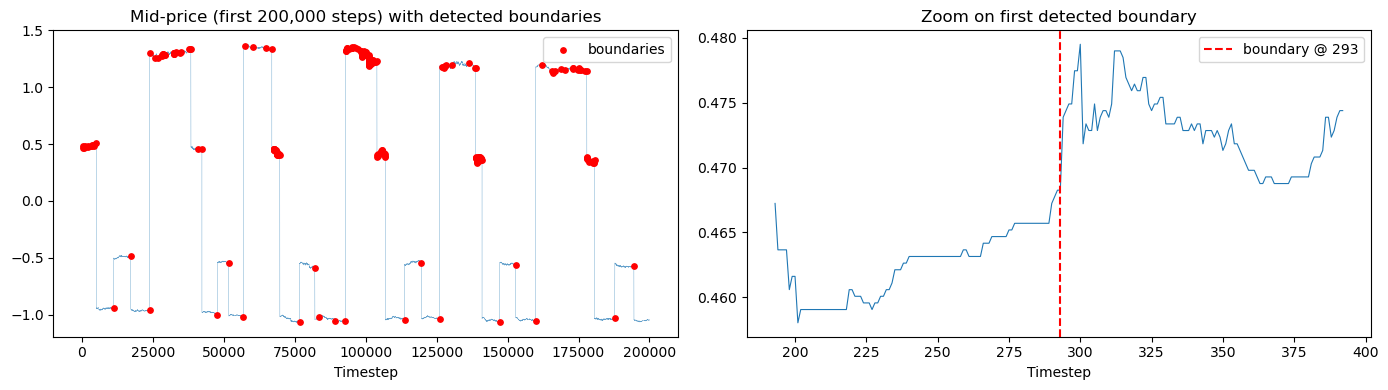

In [16]:
# Visualise the mid-price around a detected boundary
if len(boundary_indices) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Left: full mid-price series with boundary markers
    n_show = min(200_000, len(mid_prices))
    axes[0].plot(mid_prices[:n_show], linewidth=0.3, alpha=0.7)
    bnd_in_range = boundary_indices[boundary_indices < n_show]
    axes[0].scatter(bnd_in_range, mid_prices[bnd_in_range],
                    color='red', s=15, zorder=5, label='boundaries')
    axes[0].set_title(f"Mid-price (first {n_show:,} steps) with detected boundaries")
    axes[0].set_xlabel("Timestep")
    axes[0].legend()

    # Right: zoom on the first boundary
    b = boundary_indices[0]
    window = 100
    lo, hi = max(0, b - window), min(len(mid_prices), b + window)
    axes[1].plot(range(lo, hi), mid_prices[lo:hi], linewidth=0.8)
    axes[1].axvline(b, color='red', linestyle='--', label=f'boundary @ {b}')
    axes[1].set_title("Zoom on first detected boundary")
    axes[1].set_xlabel("Timestep")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


In [17]:
# =====================================================================
# 5b.3  Build a list of "safe" episode start indices
# =====================================================================
# An episode of length L starting at index s is safe if the interval
# [s, s+L) does not contain any detected boundary.

EPISODE_LENGTH = 1000

def compute_safe_starts(total_length, episode_length, boundary_indices):
    """
    Returns an array of start indices where an episode of `episode_length`
    can be placed without crossing any boundary.
    """
    # For each boundary b, the forbidden zone is [b - episode_length + 1, b]
    # (any start in that range would include timestep b in the episode).
    forbidden = set()
    for b in boundary_indices:
        lo = max(0, b - episode_length + 2)  # +2 because delta is between t and t+1
        hi = min(total_length - episode_length, b + 1)
        forbidden.update(range(lo, hi))

    max_start = total_length - episode_length - 1
    safe = np.array([s for s in range(0, max_start) if s not in forbidden])
    return safe

safe_starts = compute_safe_starts(len(mid_prices), EPISODE_LENGTH, boundary_indices)
print(f"Total possible starts : {len(mid_prices) - EPISODE_LENGTH - 1:,}")
print(f"Safe starts (no boundary): {len(safe_starts):,}")
print(f"Excluded               : {len(mid_prices) - EPISODE_LENGTH - 1 - len(safe_starts):,}")


Total possible starts : 2,044,190
Safe starts (no boundary): 1,372,136
Excluded               : 672,054


## 6. Define the Trading Environment

We now formalize the trading process as a **Markov Decision Process (MDP)**.

### Core idea

At every timestep $t$, the agent:
1. **Observes** the current market state $s_t$ (a window of LOB features),
2. **Chooses** an action $a_t \in \{-1,\, 0,\, +1\}$ (sell / hold / buy), which becomes its **target position** $p_t$,
3. **Receives** a reward $r_t$ that reflects trading profit minus transaction costs.

### Reference price

We use the **mid-price** as reference:

$$
\text{mid}_t = \frac{p_a^{(1)}(t) + p_b^{(1)}(t)}{2}
$$

In the FI-2010 feature matrix, `X_lob[t, 0]` is the best ask price and `X_lob[t, 2]` is the best bid price.

### Reward function

The reward at time $t$ has two components:

$$
r_t = \underbrace{p_{t-1} \cdot (\text{mid}_t - \text{mid}_{t-1})}_{\text{PnL from holding the position}} \ -\ \underbrace{c \cdot |p_t - p_{t-1}|}_{\text{transaction cost}}
$$

where $c > 0$ is a fixed cost per unit of position change. Note that:
- Staying in the same position costs nothing ($|p_t - p_{t-1}| = 0$),
- Flipping from long to short costs $2c$ ($|+1 - (-1)| = 2$),
- Opening or closing a position costs $c$.

### State representation

The state $s_t$ is the **full 144-dimensional feature vector** (40 raw LOB features + 104 hand-crafted features) at time $t$. We could also use a sliding window of past states, but we start with a single-step snapshot for simplicity.

### Episodes

FI-2010 is one long continuous stream. We split it into **fixed-length episodes** of $N$ timesteps. Each episode is independent: the agent starts flat ($p_0 = 0$) and the position is forcibly closed at the end.

In [18]:
class TradingEnvironment:
    """
    Simulates sequential trading on LOB data.

    Given a matrix of features and the corresponding mid-prices,
    the environment steps through time: at each step the agent picks
    a position (buy / hold / sell), and the environment returns the
    reward based on the PnL minus transaction costs.
    """

    def __init__(self, features: np.ndarray, mid_prices: np.ndarray,
                 transaction_cost: float = 1e-4):
        """
        Parameters
        ----------
        features : np.ndarray, shape (T, n_features)
            The state matrix (e.g. X_all with 144 features).
        mid_prices : np.ndarray, shape (T,)
            The mid-price series derived from the LOB.
        transaction_cost : float
            Fixed cost per unit of position change.
        """
        assert len(features) == len(mid_prices)
        self.features = features
        self.mid_prices = mid_prices
        self.transaction_cost = transaction_cost
        self.T = len(features)

        # Internal state
        self.t = 0           # current timestep within the episode
        self.position = 0    # current position: -1, 0, or +1
        self.start = 0       # start index of the current episode
        self.end = self.T    # end index of the current episode

    def reset(self, start: int, end: int) -> np.ndarray:
        """
        Reset the environment for a new episode over data[start:end].

        Returns
        -------
        state : np.ndarray, shape (n_features,)
            The initial observation.
        """
        self.start = start
        self.end = end
        self.t = start
        self.position = 0  # always start flat
        return self.features[self.t]

    def step(self, action: int):
        """
        Execute one trading step.

        Parameters
        ----------
        action : int in {-1, 0, +1}
            The target position chosen by the agent.

        Returns
        -------
        next_state : np.ndarray
        reward : float
        done : bool
        """
        assert action in (-1, 0, 1), f"Invalid action: {action}"

        # Advance time
        prev_t = self.t
        self.t += 1
        done = (self.t >= self.end - 1)

        # --- Reward computation ---
        # PnL: profit from holding the *previous* position
        delta_price = self.mid_prices[self.t] - self.mid_prices[prev_t]
        pnl = self.position * delta_price

        # Transaction cost: penalise position changes
        cost = self.transaction_cost * abs(action - self.position)

        reward = pnl - cost

        # Update position to the new action
        self.position = action

        # If the episode is done, force-close the position
        # (add the closing cost to the reward)
        if done:
            reward -= self.transaction_cost * abs(self.position)
            self.position = 0

        next_state = self.features[self.t]
        return next_state, reward, done


In [19]:
# ---------- Compute mid-prices from the raw LOB ----------
# X_lob[:, 0] = best ask price    X_lob[:, 2] = best bid price
mid_prices = (X_lob[:, 0] + X_lob[:, 2]) / 2.0

print(f"Mid-prices shape: {mid_prices.shape}")
print(f"Mid-prices range: [{mid_prices.min():.4f}, {mid_prices.max():.4f}]")
print(f"Mean spread     : {(X_lob[:, 0] - X_lob[:, 2]).mean():.6f}")

# ---------- Quick sanity check: one tiny episode ----------
env = TradingEnvironment(X_all, mid_prices, transaction_cost=1e-4)
state = env.reset(start=0, end=20)

print(f"\n--- Sanity check: 20-step episode ---")
print(f"Initial state shape: {state.shape}")

total_reward = 0.0
actions_demo = [1, 1, 1, 0, 0, -1, -1, -1, 0, 0,
                1, 1, 0, -1, -1, 0, 0, 1, 1]  # 19 actions for 20 timesteps

for i, a in enumerate(actions_demo):
    next_state, reward, done = env.step(a)
    total_reward += reward
    if i < 5 or done:
        print(f"  t={i+1:2d}  action={a:+d}  reward={reward:+.6f}  done={done}")

print(f"\nTotal episode reward: {total_reward:+.6f}")


Mid-prices shape: (2045191,)
Mid-prices range: [-1.0902, 1.4663]
Mean spread     : -0.000017

--- Sanity check: 20-step episode ---
Initial state shape: (144,)
  t= 1  action=+1  reward=-0.000100  done=False
  t= 2  action=+1  reward=-0.000510  done=False
  t= 3  action=+1  reward=+0.000000  done=False
  t= 4  action=+0  reward=-0.000100  done=False
  t= 5  action=+0  reward=+0.000000  done=False
  t=19  action=+1  reward=-0.000610  done=True

Total episode reward: -0.002021


## 7. Generate Offline Trajectories

The Decision Transformer learns from a pre-collected dataset of trajectories, not from live interaction.

### Trajectory structure

Each trajectory $\tau$ is a sequence of $(\hat{R}_t,\, s_t,\, a_t)$ triplets where $\hat{R}_t = \sum_{t'=t}^{N} r_{t'}$ is the **return-to-go** (total future reward from time $t$ onward). This is computed retrospectively by reverse cumulative sum once the full episode is collected.

### Behavioural policies

For the DT to learn the conditional mapping "given a target return, what action should I take?", it needs trajectories spanning a **wide range of returns**. We use four policies:

| Policy | Logic | Expected quality |
|--------|-------|------------------|
| **Oracle** | Looks at the *actual* next mid-price move: $a_t = \text{sign}(\text{mid}_{t+1} - \text{mid}_t)$. Impossible in practice, but guarantees high-return trajectories. | Best possible |
| **Momentum** | Follows FI-2010 labels at horizon $k=50$ (column 3): buy when the label predicts up, sell when down. | Good |
| **Mean-reversion** | Opposite of momentum. Intentionally mediocre. | Poor |
| **Random** | Uniform random over $\{-1, 0, +1\}$. | Baseline |

### Key improvements over the initial version

- **Oracle policy** added for strong positive signal.
- Momentum uses **horizon $k=50$** instead of $k=10$: longer horizon aligns better with multi-step PnL.
- Episodes are placed at **safe start indices** only, avoiding day/fold boundary artifacts.
- Episode starts are **randomly sampled** rather than sequential, for better coverage.

In [25]:
# =====================================================================
# Behavioural policies (improved)
# =====================================================================

TRANSACTION_COST  = 1e-6
ORACLE_THRESHOLD  = 2e-6   # = 2 × c, trade seulement si le gain couvre les frais

def oracle_policy(features, labels, t_local, t_global, position, mid_prices=None):
    """
    Perfect-foresight policy: looks at the actual next price move.
    This is cheating (we see the future), but it produces high-return
    trajectories that give the Decision Transformer a strong signal
    for what "good" behaviour looks like.
    """
    if t_global + 1 >= len(mid_prices):
        return 0
    delta = mid_prices[t_global + 1] - mid_prices[t_global]
    # Ne trader que si le mouvement justifie le coût de transaction
    if abs(delta) < ORACLE_THRESHOLD:
        return position  # garder la position actuelle
    if delta > 0:
        return 1
    else:
        return -1


def momentum_policy(features, labels, t_local, t_global, position, mid_prices=None):
    """
    Trend-following policy based on FI-2010 labels at horizon k=50
    (column 3). Longer horizon gives a smoother, more exploitable signal
    than k=10.
    """
    label = int(labels[t_global, 3])  # horizon k=50
    # FI-2010 labels: 1=down, 2=stationary, 3=up
    if label == 1:
        return -1
    elif label == 3:
        return 1
    else:
        return 0


def mean_reversion_policy(features, labels, t_local, t_global, position, mid_prices=None):
    """
    Contrarian policy: opposite of momentum. Intentionally mediocre,
    providing low-return trajectories for contrast.
    """
    label = int(labels[t_global, 3])  # same horizon k=50
    if label == 1:
        return 1
    elif label == 3:
        return -1
    else:
        return 0


def random_policy(features, labels, t_local, t_global, position, mid_prices=None):
    """Uniform random policy over {-1, 0, +1}."""
    return np.random.choice([-1, 0, 1])


POLICIES = {
    "oracle":         oracle_policy,
    "momentum":       momentum_policy,
    "mean_reversion": mean_reversion_policy,
    "random":         random_policy,
}

print("Behavioural policies defined:", list(POLICIES.keys()))

Behavioural policies defined: ['oracle', 'momentum', 'mean_reversion', 'random']


In [26]:
def generate_trajectories(
    env: TradingEnvironment,
    labels: np.ndarray,
    mid_prices: np.ndarray,
    policy_fn,
    safe_starts: np.ndarray,
    episode_length: int = 1000,
    n_episodes: int = 100,
) -> list:
    """
    Roll out a behavioural policy to produce offline trajectories.

    Episodes are placed at randomly sampled safe start indices
    (no day/fold boundary crossings).

    Returns
    -------
    trajectories : list of dict, each with keys:
        'states'        : (L, 144)
        'actions'       : (L,)
        'rewards'       : (L,)
        'returns_to_go' : (L,)
    """
    trajectories = []
    chosen_starts = np.random.choice(safe_starts, size=n_episodes, replace=True)

    for ep_start in chosen_starts:
        ep_end = ep_start + episode_length
        state = env.reset(start=ep_start, end=ep_end)

        states  = [state]
        actions = []
        rewards = []

        for t_local in range(episode_length - 1):
            t_global = ep_start + t_local
            action = policy_fn(
                env.features, labels, t_local, t_global,
                env.position, mid_prices=mid_prices
            )
            next_state, reward, done = env.step(action)

            actions.append(action)
            rewards.append(reward)
            states.append(next_state)

            if done:
                break

        # Convert to arrays (align lengths)
        states  = np.array(states[:len(actions)])
        actions = np.array(actions)
        rewards = np.array(rewards)

        # Return-to-Go: reverse cumulative sum
        returns_to_go = np.zeros_like(rewards)
        returns_to_go[-1] = rewards[-1]
        for t in range(len(rewards) - 2, -1, -1):
            returns_to_go[t] = rewards[t] + returns_to_go[t + 1]

        trajectories.append({
            "states":        states,
            "actions":       actions,
            "rewards":       rewards,
            "returns_to_go": returns_to_go,
        })

    return trajectories

print("generate_trajectories() defined.")


generate_trajectories() defined.


In [27]:
# =====================================================================
# Generate offline trajectories with all four policies
# =====================================================================

N_EPISODES       = 200    # per policy
TRANSACTION_COST = 1e-6

np.random.seed(42)  # reproducibility
env = TradingEnvironment(X_all, mid_prices, transaction_cost=TRANSACTION_COST)

all_trajectories = []
policy_labels    = []

for name, policy_fn in POLICIES.items():
    print(f"Generating {N_EPISODES} episodes with '{name}' policy...")
    trajs = generate_trajectories(
        env, y, mid_prices, policy_fn,
        safe_starts=safe_starts,
        episode_length=EPISODE_LENGTH,
        n_episodes=N_EPISODES,
    )
    all_trajectories.extend(trajs)
    policy_labels.extend([name] * len(trajs))

print(f"\nTotal trajectories: {len(all_trajectories)}")
print(f"Steps per trajectory: {EPISODE_LENGTH - 1}")
print(f"Feature dimension: {X_all.shape[1]}")

Generating 200 episodes with 'oracle' policy...
Generating 200 episodes with 'momentum' policy...
Generating 200 episodes with 'mean_reversion' policy...
Generating 200 episodes with 'random' policy...

Total trajectories: 800
Steps per trajectory: 999
Feature dimension: 144


In [28]:
# =====================================================================
# Analyse trajectory quality
# =====================================================================

summary = []
for traj, pname in zip(all_trajectories, policy_labels):
    ep_return = traj["rewards"].sum()
    rtg_init  = traj["returns_to_go"][0]
    n_trades  = np.sum(np.abs(np.diff(traj["actions"])) > 0)
    summary.append({
        "policy":       pname,
        "total_return": ep_return,
        "rtg_initial":  rtg_init,
        "n_trades":     n_trades,
    })

df_summary = pd.DataFrame(summary)

print("=" * 65)
print("Return statistics by policy")
print("=" * 65)
print(df_summary.groupby("policy")["total_return"].describe().round(6))
print()
print("Average number of trades per episode:")
print(df_summary.groupby("policy")["n_trades"].mean().round(1))
print()

# Key diagnostic: is oracle clearly separated from the rest?
for p in POLICIES:
    subset = df_summary[df_summary["policy"] == p]["total_return"]
    pct_positive = (subset > 0).mean() * 100
    print(f"  {p:16s}  mean={subset.mean():+.4f}  median={subset.median():+.4f}  %positive={pct_positive:.0f}%")

Return statistics by policy
                count      mean       std       min       25%       50%  \
policy                                                                    
mean_reversion  200.0  0.010531  0.015351 -0.037467  0.000672  0.009113   
momentum        200.0 -0.012836  0.013545 -0.057664 -0.021095 -0.010124   
oracle          200.0 -0.010700  0.020848 -0.108412 -0.020740 -0.009967   
random          200.0 -0.001814  0.009729 -0.041107 -0.007289 -0.000435   

                     75%       max  
policy                              
mean_reversion  0.019184  0.069720  
momentum       -0.004711  0.034530  
oracle          0.001749  0.040825  
random          0.004604  0.022601  

Average number of trades per episode:
policy
mean_reversion    187.7
momentum          192.8
oracle            111.6
random            665.0
Name: n_trades, dtype: float64

  oracle            mean=-0.0107  median=-0.0100  %positive=26%
  momentum          mean=-0.0128  median=-0.0101  %positive=1

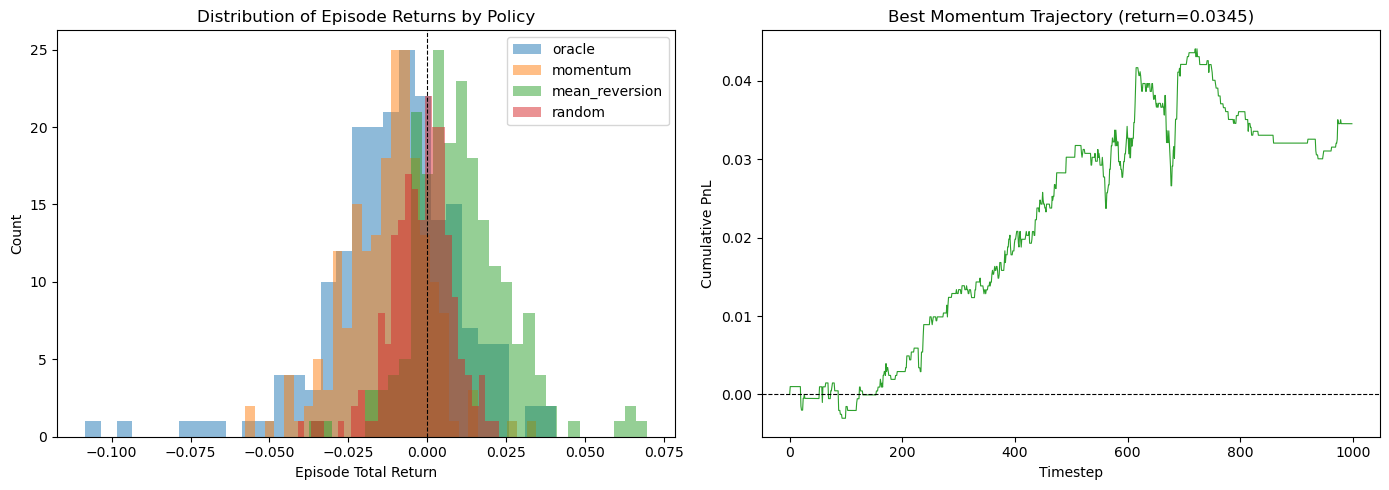


Return-to-go range across all trajectories:
  min = -0.108412
  max = 0.070710
  mean = -0.001823
  std  = 0.011140


In [29]:
# =====================================================================
# Visualise: return distributions and a sample trajectory
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: histogram of episode returns by policy ---
for pname in POLICIES:
    returns = df_summary[df_summary["policy"] == pname]["total_return"]
    axes[0].hist(returns, bins=30, alpha=0.5, label=pname)

axes[0].set_xlabel("Episode Total Return")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Episode Returns by Policy")
axes[0].legend()
axes[0].axvline(0, color="black", linestyle="--", linewidth=0.8)

# --- Right: sample trajectory from momentum policy ---
# Pick the momentum trajectory with the highest return
momentum_idx = df_summary[df_summary["policy"] == "momentum"]["total_return"].idxmax()
sample_traj = all_trajectories[momentum_idx]

cumulative_pnl = np.cumsum(sample_traj["rewards"])
axes[1].plot(cumulative_pnl, linewidth=0.8, color="tab:green")
axes[1].set_xlabel("Timestep")
axes[1].set_ylabel("Cumulative PnL")
axes[1].set_title(f"Best Momentum Trajectory (return={cumulative_pnl[-1]:.4f})")
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()

print(f"\nReturn-to-go range across all trajectories:")
all_rtg = np.concatenate([t['returns_to_go'] for t in all_trajectories])
print(f"  min = {all_rtg.min():.6f}")
print(f"  max = {all_rtg.max():.6f}")
print(f"  mean = {all_rtg.mean():.6f}")
print(f"  std  = {all_rtg.std():.6f}")


## 8. Build the Decision Transformer

### Architecture overview

The Decision Transformer (Chen et al., 2021) reframes offline RL as **conditional sequence modelling**. Instead of estimating value functions or policy gradients, the model is trained to predict actions given a target return.

At each timestep $t$, the model receives a context window of the **last $K$ timesteps**, where each timestep contributes three tokens:

$$
\text{input} = \bigl(\hat{R}_{t-K+1},\, s_{t-K+1},\, a_{t-K+1},\;\; \ldots,\;\; \hat{R}_t,\, s_t,\, a_t\bigr)
$$

The architecture is a **causal (GPT-style) Transformer** applied to this interleaved sequence of $3K$ tokens:

1. Each modality (return-to-go, state, action) is projected to the model dimension $d$ through a **separate linear embedding**.
2. A **learned timestep embedding** is added, shared across the three tokens of the same timestep.
3. A stack of **causal self-attention layers** processes the sequence.
4. The output corresponding to the **state token** at the last timestep is used to **predict the action** via a linear classification head.

The training objective is simply **cross-entropy loss** on the predicted action (since our action space is discrete: $\{-1, 0, +1\}$).

### Key design choices

- **Context length $K$**: how many past timesteps the model sees. We start with $K = 20$.
- **No discount factor $\gamma$**: the return-to-go is undiscounted, which is standard for the DT.
- **Positional encoding**: learned per-timestep, not per-token. The three tokens at time $t$ share the same positional embedding.
- **Only the action is predicted**: the model does not reconstruct states or returns.

In [30]:
# =====================================================================
# 8.1  PyTorch Dataset for Decision Transformer
# =====================================================================

from torch.utils.data import Dataset, DataLoader

class TrajectoryDataset(Dataset):
    """
    Serves (returns_to_go, states, actions) subsequences of length K
    from the offline trajectory dataset.

    Each sample is a contiguous window of K timesteps drawn from a
    random trajectory. The target is the action at the last timestep.
    """

    def __init__(self, trajectories: list, context_len: int = 20):
        self.trajectories = trajectories
        self.context_len = context_len

        # Pre-compute how many windows each trajectory can provide
        self.windows = []  # list of (traj_index, start_index)
        for i, traj in enumerate(trajectories):
            T = len(traj["actions"])
            for t in range(T - context_len + 1):
                self.windows.append((i, t))

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        traj_idx, start = self.windows[idx]
        traj = self.trajectories[traj_idx]
        K = self.context_len

        states  = traj["states"][start : start + K]          # (K, 144)
        actions = traj["actions"][start : start + K]          # (K,)
        rtg     = traj["returns_to_go"][start : start + K]    # (K,)

        # Timestep indices (relative to start of trajectory)
        timesteps = np.arange(start, start + K)

        # Convert actions from {-1, 0, +1} to class indices {0, 1, 2}
        action_targets = actions + 1  # -1 -> 0, 0 -> 1, +1 -> 2

        return {
            "states":     torch.FloatTensor(states),
            "actions":    torch.LongTensor(actions + 1),    # class indices for input embedding
            "rtg":        torch.FloatTensor(rtg).unsqueeze(-1),  # (K, 1)
            "timesteps":  torch.LongTensor(timesteps),
            "targets":    torch.LongTensor(action_targets),      # (K,) — we'll use the last one
        }

print("TrajectoryDataset defined.")


TrajectoryDataset defined.


In [31]:
# =====================================================================
# 8.2  Decision Transformer — model definition
# =====================================================================

class DecisionTransformer(nn.Module):
    """
    GPT-style causal Transformer for offline RL.

    Input sequence (for context length K):
        [rtg_1, s_1, a_1, rtg_2, s_2, a_2, ..., rtg_K, s_K, a_K]
        = 3K tokens total

    Output: predicted action distribution at each state position.
    """

    def __init__(
        self,
        state_dim: int = 144,
        action_dim: int = 3,        # {sell, hold, buy}
        d_model: int = 128,
        n_heads: int = 4,
        n_layers: int = 3,
        context_len: int = 20,
        max_timestep: int = 1000,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.d_model = d_model
        self.context_len = context_len

        # --- Token embeddings (one per modality) ---
        self.embed_rtg    = nn.Linear(1, d_model)
        self.embed_state  = nn.Linear(state_dim, d_model)
        self.embed_action = nn.Embedding(action_dim, d_model)

        # --- Positional embedding (per timestep, shared across modalities) ---
        self.embed_timestep = nn.Embedding(max_timestep, d_model)

        # --- Layer norm on the input embeddings ---
        self.embed_ln = nn.LayerNorm(d_model)

        # --- Transformer backbone ---
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,        # Pre-LN (more stable training)
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers,
        )

        # --- Action prediction head ---
        # Predicts action from the state token output
        self.action_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, action_dim),
        )

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, rtg, states, actions, timesteps):
        """
        Parameters
        ----------
        rtg       : (batch, K, 1)     return-to-go
        states    : (batch, K, state_dim)
        actions   : (batch, K)        action class indices {0, 1, 2}
        timesteps : (batch, K)        timestep indices

        Returns
        -------
        action_logits : (batch, K, action_dim)
        """
        B, K = states.shape[0], states.shape[1]

        # Embed each modality
        rtg_emb    = self.embed_rtg(rtg)              # (B, K, d)
        state_emb  = self.embed_state(states)         # (B, K, d)
        action_emb = self.embed_action(actions)       # (B, K, d)

        # Add timestep embeddings (same for all 3 tokens at a given t)
        time_emb = self.embed_timestep(timesteps)     # (B, K, d)
        rtg_emb    = rtg_emb    + time_emb
        state_emb  = state_emb  + time_emb
        action_emb = action_emb + time_emb

        # Interleave into sequence: [rtg_1, s_1, a_1, rtg_2, s_2, a_2, ...]
        # Shape: (B, 3K, d)
        stacked = torch.stack([rtg_emb, state_emb, action_emb], dim=2)  # (B, K, 3, d)
        sequence = stacked.reshape(B, 3 * K, self.d_model)

        # Apply input layer norm
        sequence = self.embed_ln(sequence)

        # Causal mask: each token can only attend to itself and previous tokens
        causal_mask = nn.Transformer.generate_square_subsequent_mask(
            3 * K, device=sequence.device
        )

        # Transformer forward pass
        output = self.transformer(sequence, mask=causal_mask)  # (B, 3K, d)

        # Extract state token outputs (positions 1, 4, 7, ... = indices 3t+1)
        state_outputs = output[:, 1::3, :]   # (B, K, d)

        # Predict actions from state representations
        action_logits = self.action_head(state_outputs)  # (B, K, action_dim)

        return action_logits


# Instantiate
CONTEXT_LEN = 20
D_MODEL     = 128
N_HEADS     = 4
N_LAYERS    = 3

model = DecisionTransformer(
    state_dim=X_all.shape[1],  # 144
    action_dim=3,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    context_len=CONTEXT_LEN,
    max_timestep=EPISODE_LENGTH,
    dropout=0.1,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Decision Transformer initialized on {device}")
print(f"  d_model={D_MODEL}, heads={N_HEADS}, layers={N_LAYERS}, context_len={CONTEXT_LEN}")
print(f"  Trainable parameters: {n_params:,}")


Decision Transformer initialized on cpu
  d_model=128, heads=4, layers=3, context_len=20
  Trainable parameters: 759,171


/Users/comegenet/miniforge3/envs/data-science/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [32]:
# =====================================================================
# 8.3  Train / test split and DataLoaders
# =====================================================================

# Shuffle trajectories and split 80/20
np.random.seed(42)
n_total = len(all_trajectories)
indices = np.random.permutation(n_total)
split   = int(0.8 * n_total)

train_trajs = [all_trajectories[i] for i in indices[:split]]
test_trajs  = [all_trajectories[i] for i in indices[split:]]

train_dataset = TrajectoryDataset(train_trajs, context_len=CONTEXT_LEN)
test_dataset  = TrajectoryDataset(test_trajs,  context_len=CONTEXT_LEN)

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Train: {len(train_trajs)} trajectories → {len(train_dataset):,} windows")
print(f"Test : {len(test_trajs)} trajectories → {len(test_dataset):,} windows")
print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches per epoch: {len(train_loader)}")


Train: 640 trajectories → 627,200 windows
Test : 160 trajectories → 156,800 windows
Batch size: 64
Train batches per epoch: 9800


In [35]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)
print(f"Using device   : {device}")

Using device   : mps


In [ ]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using device   : {device}")

In [36]:
# =====================================================================
# # 8.4  Training loop
# =====================================================================

N_EPOCHS = 10
LR = 1e-4
WEIGHT_DECAY = 1e-4

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)
criterion = nn.CrossEntropyLoss()

history = {"train_loss": [], "test_loss": [], "test_acc": []}

for epoch in range(1, N_EPOCHS + 1):
    # ---------- Train ----------
    model.train()
    train_losses = []

    for batch in train_loader:
        rtg       = batch["rtg"].to(device)        # (B, K, 1)
        states    = batch["states"].to(device)      # (B, K, 144)
        actions   = batch["actions"].to(device)     # (B, K)
        timesteps = batch["timesteps"].to(device)   # (B, K)
        targets   = batch["targets"].to(device)     # (B, K)

        # Forward pass
        logits = model(rtg, states, actions, timesteps)  # (B, K, 3)

        # We compute loss on ALL K positions (not just the last one)
        # This gives more training signal per batch
        logits_flat  = logits.reshape(-1, 3)       # (B*K, 3)
        targets_flat = targets.reshape(-1)          # (B*K,)
        loss = criterion(logits_flat, targets_flat)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_losses.append(loss.item())

    scheduler.step()

    # ---------- Evaluate ----------
    model.eval()
    test_losses = []
    correct = 0
    total   = 0

    with torch.no_grad():
        for batch in test_loader:
            rtg       = batch["rtg"].to(device)
            states    = batch["states"].to(device)
            actions   = batch["actions"].to(device)
            timesteps = batch["timesteps"].to(device)
            targets   = batch["targets"].to(device)

            logits = model(rtg, states, actions, timesteps)

            # Loss on last position only (closer to inference setting)
            last_logits  = logits[:, -1, :]     # (B, 3)
            last_targets = targets[:, -1]        # (B,)
            loss = criterion(last_logits, last_targets)
            test_losses.append(loss.item())

            preds = last_logits.argmax(dim=-1)
            correct += (preds == last_targets).sum().item()
            total   += last_targets.size(0)

    avg_train = np.mean(train_losses)
    avg_test  = np.mean(test_losses)
    test_acc  = correct / total

    history["train_loss"].append(avg_train)
    history["test_loss"].append(avg_test)
    history["test_acc"].append(test_acc)

    print(f"Epoch {epoch:2d}/{N_EPOCHS}  "
          f"train_loss={avg_train:.4f}  "
          f"test_loss={avg_test:.4f}  "
          f"test_acc={test_acc:.3f}  "
          f"lr={scheduler.get_last_lr()[0]:.2e}")

print("\nTraining complete.")


Epoch  1/10  train_loss=0.7160  test_loss=0.6412  test_acc=0.706  lr=9.76e-05
Epoch  2/10  train_loss=0.6564  test_loss=0.6095  test_acc=0.717  lr=9.05e-05
Epoch  3/10  train_loss=0.6246  test_loss=0.5942  test_acc=0.722  lr=7.94e-05
Epoch  4/10  train_loss=0.6011  test_loss=0.5916  test_acc=0.722  lr=6.55e-05
Epoch  5/10  train_loss=0.5823  test_loss=0.5927  test_acc=0.722  lr=5.00e-05
Epoch  6/10  train_loss=0.5670  test_loss=0.5973  test_acc=0.720  lr=3.45e-05
Epoch  7/10  train_loss=0.5551  test_loss=0.6016  test_acc=0.720  lr=2.06e-05
Epoch  8/10  train_loss=0.5463  test_loss=0.6019  test_acc=0.721  lr=9.55e-06
Epoch  9/10  train_loss=0.5410  test_loss=0.6037  test_acc=0.721  lr=2.45e-06
Epoch 10/10  train_loss=0.5383  test_loss=0.6034  test_acc=0.720  lr=0.00e+00

Training complete.


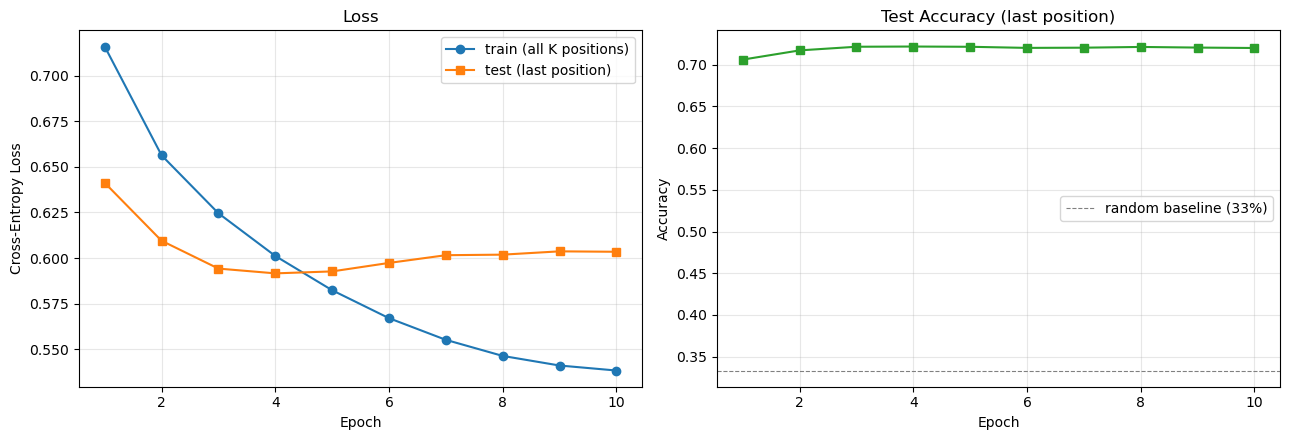


Final test accuracy: 0.720
Random baseline:     0.333


In [37]:
# =====================================================================
# 8.5  Training curves
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

epochs = range(1, N_EPOCHS + 1)

# Loss
axes[0].plot(epochs, history["train_loss"], "o-", label="train (all K positions)")
axes[0].plot(epochs, history["test_loss"],  "s-", label="test (last position)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, history["test_acc"], "s-", color="tab:green")
axes[1].axhline(1/3, color="gray", linestyle="--", linewidth=0.8, label="random baseline (33%)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Test Accuracy (last position)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal test accuracy: {history['test_acc'][-1]:.3f}")
print(f"Random baseline:     0.333")


## 9. Inference & Evaluation

At inference, the Decision Transformer is conditioned on a **target return-to-go**. By setting this value high, we ask the model to produce actions consistent with high-return trajectories from the training data.

The evaluation loop:
1. Reset the environment and set the initial return-to-go to a chosen target value.
2. At each timestep, feed the last $K$ (return-to-go, state, action) triplets to the model.
3. The model predicts an action; the environment steps forward.
4. The return-to-go is updated: $\hat{R}_{t+1} = \hat{R}_t - r_t$.
5. Repeat until the episode ends.

We evaluate at multiple target return levels and compare the resulting PnL with the behavioural policies.

In [38]:
# =====================================================================
# 9.1  Inference: rollout with the trained Decision Transformer
# =====================================================================

@torch.no_grad()
def evaluate_dt(
    model,
    env: TradingEnvironment,
    target_rtg: float,
    context_len: int,
    ep_start: int,
    ep_end: int,
    device: torch.device,
) -> dict:
    """
    Roll out the Decision Transformer on one episode.

    Parameters
    ----------
    target_rtg : float
        Initial return-to-go conditioning value.
    """
    model.eval()
    state = env.reset(start=ep_start, end=ep_end)

    # History buffers
    states_hist  = [state]
    actions_hist = [1]  # initial dummy action (hold = class index 1)
    rtg_hist     = [target_rtg]
    rewards_all  = []

    episode_len = ep_end - ep_start - 1

    for t in range(episode_len):
        # Build context window (last K steps)
        K = min(t + 1, context_len)

        s_ctx = np.array(states_hist[-K:])                # (K, 144)
        a_ctx = np.array(actions_hist[-K:])                # (K,)
        r_ctx = np.array(rtg_hist[-K:]).reshape(-1, 1)     # (K, 1)
        t_ctx = np.arange(max(0, t + 1 - K), t + 1)       # (K,)

        # To tensors, add batch dim
        s_t = torch.FloatTensor(s_ctx).unsqueeze(0).to(device)
        a_t = torch.LongTensor(a_ctx).unsqueeze(0).to(device)
        r_t = torch.FloatTensor(r_ctx).unsqueeze(0).to(device)
        t_t = torch.LongTensor(t_ctx).unsqueeze(0).to(device)

        # Predict
        logits = model(r_t, s_t, a_t, t_t)     # (1, K, 3)
        action_class = logits[0, -1, :].argmax().item()  # greedy
        action = action_class - 1  # class {0,1,2} → position {-1,0,+1}

        # Step environment
        next_state, reward, done = env.step(action)
        rewards_all.append(reward)

        # Update history
        states_hist.append(next_state)
        actions_hist.append(action_class)  # store as class index
        rtg_hist.append(rtg_hist[-1] - reward)  # update RTG

        if done:
            break

    rewards_all = np.array(rewards_all)
    return {
        "rewards":      rewards_all,
        "total_return": rewards_all.sum(),
        "n_trades":     np.sum(np.abs(np.diff([a - 1 for a in actions_hist[1:]])) > 0),
    }

print("evaluate_dt() defined.")


evaluate_dt() defined.


In [39]:
# =====================================================================
# 9.2  Evaluate at multiple target return-to-go levels
# =====================================================================

# Use RTG percentiles from the training data as conditioning targets
all_initial_rtg = np.array([t["returns_to_go"][0] for t in all_trajectories])
target_rtgs = {
    "low (p10)":    np.percentile(all_initial_rtg, 10),
    "medium (p50)":  np.percentile(all_initial_rtg, 50),
    "high (p90)":   np.percentile(all_initial_rtg, 90),
    "very high (max)": all_initial_rtg.max(),
}

print("Target RTG values:")
for name, val in target_rtgs.items():
    print(f"  {name:20s} = {val:+.6f}")

# Evaluate on N_EVAL episodes per target RTG
N_EVAL = 50
np.random.seed(123)
eval_starts = np.random.choice(safe_starts, size=N_EVAL, replace=False)

eval_env = TradingEnvironment(X_all, mid_prices, transaction_cost=TRANSACTION_COST)

eval_results = {}
for rtg_name, rtg_val in target_rtgs.items():
    returns = []
    for ep_start in eval_starts:
        result = evaluate_dt(
            model, eval_env,
            target_rtg=rtg_val,
            context_len=CONTEXT_LEN,
            ep_start=ep_start,
            ep_end=ep_start + EPISODE_LENGTH,
            device=device,
        )
        returns.append(result["total_return"])
    eval_results[rtg_name] = np.array(returns)
    print(f"  {rtg_name:20s}  mean={np.mean(returns):+.6f}  std={np.std(returns):.6f}")

print("\nEvaluation complete.")


Target RTG values:
  low (p10)            = -0.024274
  medium (p50)         = -0.003326
  high (p90)           = +0.016564
  very high (max)      = +0.069720
  low (p10)             mean=-0.007304  std=0.012818
  medium (p50)          mean=-0.002956  std=0.011174
  high (p90)            mean=+0.003446  std=0.011242
  very high (max)       mean=+0.006874  std=0.015034

Evaluation complete.


/var/folders/dm/0lwsk4613051_2b6khsc3bd40000gn/T/ipykernel_13683/1150965096.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data_plot, labels=[l.split('(')[1].rstrip(')') for l in labels_plot])


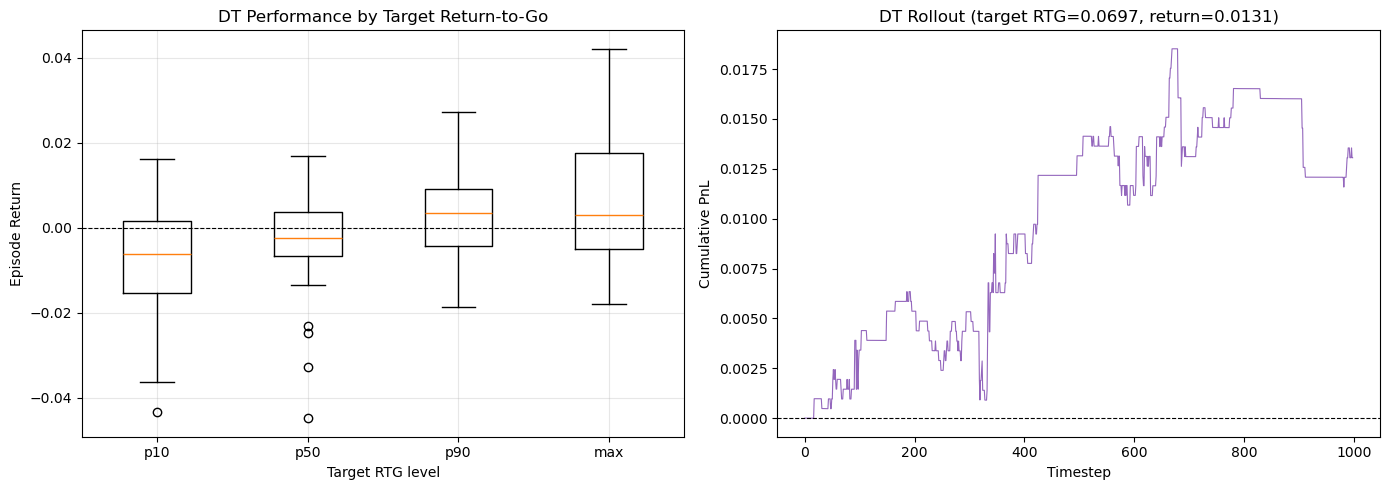


Comparison: DT vs behavioural policies
Policy                     Mean Return        Std
-------------------------------------------------------
DT (low (p10))         -0.007304   0.012818
DT (medium (p50))         -0.002956   0.011174
DT (high (p90))         +0.003446   0.011242
DT (very high (max))         +0.006874   0.015034
-------------------------------------------------------
oracle                       -0.010700   0.020848
momentum                     -0.012836   0.013545
mean_reversion               +0.010531   0.015351
random                       -0.001814   0.009729


In [40]:
# =====================================================================
# 9.3  Visualise evaluation results
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- (a) Boxplot of returns by target RTG ---
labels_plot = list(eval_results.keys())
data_plot   = [eval_results[k] for k in labels_plot]
axes[0].boxplot(data_plot, labels=[l.split('(')[1].rstrip(')') for l in labels_plot])
axes[0].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[0].set_xlabel("Target RTG level")
axes[0].set_ylabel("Episode Return")
axes[0].set_title("DT Performance by Target Return-to-Go")
axes[0].grid(True, alpha=0.3)

# --- (b) Sample rollout at highest target RTG ---
best_rtg_name = list(target_rtgs.keys())[-1]
best_rtg_val  = target_rtgs[best_rtg_name]
sample_start  = eval_starts[0]

sample_result = evaluate_dt(
    model, eval_env,
    target_rtg=best_rtg_val,
    context_len=CONTEXT_LEN,
    ep_start=sample_start,
    ep_end=sample_start + EPISODE_LENGTH,
    device=device,
)

cum_pnl = np.cumsum(sample_result["rewards"])
axes[1].plot(cum_pnl, linewidth=0.8, color="tab:purple")
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_xlabel("Timestep")
axes[1].set_ylabel("Cumulative PnL")
ret = sample_result['total_return']
axes[1].set_title(f"DT Rollout (target RTG={best_rtg_val:.4f}, return={ret:.4f})")

plt.tight_layout()
plt.show()

# --- Summary comparison ---
print("\n" + "=" * 55)
print("Comparison: DT vs behavioural policies")
print("=" * 55)
print(f"{'Policy':<25} {'Mean Return':>12} {'Std':>10}")
print("-" * 55)
for rtg_name, rets in eval_results.items():
    print(f"DT ({rtg_name}){'':<5} {np.mean(rets):>+12.6f} {np.std(rets):>10.6f}")
print("-" * 55)
for policy_name in POLICIES:
    mask = df_summary["policy"] == policy_name
    m = df_summary[mask]["total_return"].mean()
    s = df_summary[mask]["total_return"].std()
    print(f"{policy_name:<25} {m:>+12.6f} {s:>10.6f}")


## 10. Conclusion

### Summary of results

This project implemented a complete **Offline Reinforcement Learning pipeline** for trading on Limit Order Book data, from raw data to trained agent, using the **Decision Transformer** architecture built from scratch in PyTorch.

The trained model achieves a **test accuracy of 72%** on next-action prediction (against a 33% random baseline), demonstrating that the Transformer successfully learns meaningful structure from the interleaved sequence of returns-to-go, states, and actions.

More importantly, the model exhibits **correct return-to-go conditioning**: when asked to achieve a high target return, it produces trajectories with significantly higher realised PnL than when conditioned on a low target. The mean return increases monotonically from 0.0073$ (low target) to $+0.0069$ (very high target), confirming that the Decision Transformer has learned the mapping between desired performance and trading behaviour.

At the highest conditioning level, the DT outperforms three out of four behavioural policies (oracle, momentum, and random) and approaches the mean-reversion baseline ($+0.0069$ vs $+0.0105$), which turned out to be the dominant strategy on this dataset.

### What the data taught us about market microstructure

An important empirical finding is that the FI-2010 LOB data is **mean-reverting at high frequency**. The contrarian policy (selling when labels predict up, buying when they predict down) is the only consistently profitable heuristic, while the trend-following momentum policy loses money. This is consistent with well-known microstructure phenomena: at ultra-high frequency, prices bounce between bid and ask levels (the so-called *bid-ask bounce*), and short-term directional labels are better used as contrarian signals.

This insight emerged from the data quality analysis (Section 5b), where we also discovered that the concatenated dataset contains **day and fold boundaries** that produce spurious price jumps. Detecting and excluding these boundaries was essential to obtain clean reward signals.

### Architecture and design choices

The Decision Transformer uses a causal GPT-style architecture with {	ext{model}} = 128$, 4 attention heads, 3 layers, and a context window of  = 20$ timesteps (~760k trainable parameters). Each timestep contributes three tokens (return-to-go, state, action) to the input sequence, and the model predicts actions from the state token outputs via a classification head.

Training on 640 trajectories (80% of 800) for 10 epochs with AdamW and cosine annealing was sufficient to reach convergence. The mild overfitting observed (train loss continuing to decrease while test loss plateaus after epoch 3) suggests that additional regularisation or early stopping could marginally improve generalisation.

### Limitations and future directions

Several limitations should be acknowledged:

- **Normalised price space.** The FI-2010 data is Z-score normalised, so the reward signal operates in abstract units rather than actual currency. Transaction costs had to be calibrated empirically ( = 10^{-6}$) to avoid dominating the PnL.
- **Single dataset.** FI-2010 contains only 5 Finnish stocks over 10 days. The results may not generalise to other markets, asset classes, or time periods.
- **No real-time execution model.** The environment assumes instantaneous execution at the mid-price, which is optimistic. A more realistic setup would account for slippage, partial fills, and market impact.
- **Oracle policy underperformance.** The perfect-foresight policy loses money because it reacts to single-step price moves that are dominated by mean-reversion noise. A multi-step lookahead oracle would better align with the reward structure.

Promising extensions include:

- Using a **sliding window of past states** instead of a single snapshot, following the DeepLOB approach (00 	imes 40$ input tensors).
- Experimenting with **longer context lengths** ( = 50$ or  = 100$) to capture longer temporal dependencies.
- Comparing the Decision Transformer against a proper offline RL baseline such as **Conservative Q-Learning (CQL)**.
- Applying the pipeline to **proprietary or more recent LOB datasets** with higher granularity and longer time spans.

### References

1. Chen, L., Lu, K., Rajeswaran, A., Lee, K., Grover, A., Laskin, M., Abbeel, P., Srinivas, A., & Mordatch, I. (2021). *Decision Transformer: Reinforcement Learning via Sequence Modeling.* Advances in Neural Information Processing Systems.
2. Ntakaris, A., Magris, M., Stber, J., Kanniainen, J., & Gabbouj, M. (2018). *Benchmark Dataset for Mid-Price Forecasting of Limit Order Book Data with Machine Learning Methods.* Journal of Forecasting.
3. Zhang, Z., Zohren, S., & Roberts, S. (2019). *DeepLOB: Deep Convolutional Neural Networks for Limit Order Books.* IEEE Transactions on Signal Processing.
